In [1]:
!pip install nltk wordcloud

In [2]:
import re      # importing regular expressions module (used for pattern matching in text)
import nltk    # importing nltk library (used for natural language processing tasks)

import matplotlib.pyplot as plt    # importing matplotlib for plotting graphs
from nltk.tokenize import word_tokenize, sent_tokenize    # importing functions to break text into words and sentences

from collections import Counter     # Counter helps count frequency of words
from wordcloud import WordCloud     # WordCloud is used to create a visual of most frequent words

nltk.download('punkt_tab')    # downloading punkt_tab (used for tokenizing text into words and sentences)
nltk.download('stopwords')    # downloading stopwords (common words like "the", "is" which we usually ignore)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
# import file upload option in Colab
from google.colab import files

# upload files from your computer
uploaded = files.upload()

Saving NLU_assignment.txt to NLU_assignment.txt


In [4]:
# open the text file in read mode
with open("NLU_assignment.txt", "r", encoding="utf-8") as file:
    text = file.read()  # read full content of file

# print first 500 characters (just preview)
print(text[:500])

Indian Institute of Technology Jodhpur was established in 2008 to foster technology education and research in India. The institute is committed to technological thought and action to benefit the economic development of India. Scholarship in teaching and learning, scholarship in research and creative accomplishments, and relevance to industry are three driving forces at IIT Jodhpur.

IIT Jodhpur functions from its sprawling residential permanent campus of 852 acres on National Highway 65, north n


In [5]:
# importing stopwords list from nltk
from nltk.corpus import stopwords

# get default English stopwords
stop_words = set(stopwords.words('english'))

# adding some extra custom stopwords
extra_stopwords = ["may", "must", "would", "could", "also", "among", "however", "etc", "September",
"one", "two", "three", "four", "five", "six", "seven", "eight", "nine", "ten",
"talk", "within", "without", "day", "use", "atleast", "using", "per",
"first", "second", "third", "start", "end"]

# update main stopwords set
stop_words.update(extra_stopwords)

# print total number of stopwords
print("Total stopwords now:", len(stop_words))

Total stopwords now: 230


In [6]:
# converting all text to lowercase
text_lower = text.lower()

# removing special characters but keeping .
text_for_sentences = re.sub(r'[^\w\s.]', '', text_lower)

# splitting text into sentences
sentences = sent_tokenize(text_for_sentences)

# list to store cleaned sentences
processed_sentences = []

for sent in sentences:
    words = word_tokenize(sent)    # splitting sentence into words
    words = [w for w in words if w.isalpha() and len(w) > 2]    # keeping only alphabetic words with length > 2
    if len(words) > 2:    # ignoring very short sentences
        processed_sentences.append(words)    # adding cleaned sentence

print("Number of sentences:", len(processed_sentences))    # printing total sentences
print("Sample tokenized sentences:\n", processed_sentences[:5])    # printing first 5 sentences

Number of sentences: 1942
Sample tokenized sentences:
 [['indian', 'institute', 'technology', 'jodhpur', 'was', 'established', 'foster', 'technology', 'education', 'and', 'research', 'india'], ['the', 'institute', 'committed', 'technological', 'thought', 'and', 'action', 'benefit', 'the', 'economic', 'development', 'india'], ['scholarship', 'teaching', 'and', 'learning', 'scholarship', 'research', 'and', 'creative', 'accomplishments', 'and', 'relevance', 'industry', 'are', 'three', 'driving', 'forces', 'iit', 'jodhpur'], ['iit', 'jodhpur', 'functions', 'from', 'its', 'sprawling', 'residential', 'permanent', 'campus', 'acres', 'national', 'highway', 'north', 'northwest', 'jodhpur', 'towards', 'nagaur'], ['this', 'campus', 'meticulously', 'planned', 'and', 'envisioned', 'stand', 'symbol', 'academics', 'that', 'simple', 'but', 'deep']]


In [7]:
processed_sentences_nostop = []    # list to store sentences after removing stopwords

# Merge common word forms into one base form
merge_dict = {
    "students":     "student",
    "programs":     "program",
    "technologies": "technology",
    "universities": "university",
    "facilities":   "facility",
    "departments":  "department",
    "activities":   "activity",
    "laboratories": "laboratory",
    "regulations":  "regulation",
    "scholarships": "scholarship",
    "achievements": "achievement",
    "researchers":  "researcher",
    "professors":   "professor",
    "publications": "publication",
    "courses":      "course",
    "members":      "member",
    "centers":      "center",
    "centres":      "center",   # handling different spelling
}

for sentence in processed_sentences:
    filtered_words = []    # list for cleaned words in each sentence
    for w in sentence:
        if w in stop_words:
            continue    # skip stopwords
        clean_w = merge_dict.get(w, w)    # replace with base form if exists
        filtered_words.append(clean_w)
    if len(filtered_words) > 0:
        processed_sentences_nostop.append(filtered_words)    # add cleaned sentence

print("Sample sentences after stopword removal + word merging:")
print(processed_sentences_nostop[:5])    # print first 5 sentences

Sample sentences after stopword removal + word merging:
[['indian', 'institute', 'technology', 'jodhpur', 'established', 'foster', 'technology', 'education', 'research', 'india'], ['institute', 'committed', 'technological', 'thought', 'action', 'benefit', 'economic', 'development', 'india'], ['scholarship', 'teaching', 'learning', 'scholarship', 'research', 'creative', 'accomplishments', 'relevance', 'industry', 'driving', 'forces', 'iit', 'jodhpur'], ['iit', 'jodhpur', 'functions', 'sprawling', 'residential', 'permanent', 'campus', 'acres', 'national', 'highway', 'north', 'northwest', 'jodhpur', 'towards', 'nagaur'], ['campus', 'meticulously', 'planned', 'envisioned', 'stand', 'symbol', 'academics', 'simple', 'deep']]


In [8]:
# removing all digits from text
clean_text = re.sub(r'\d+', '', text_lower)

# removing special characters
clean_text = re.sub(r'[^\w\s]','',clean_text)

# remove extra spaces
clean_text = re.sub(r'\s+',' ',clean_text)

# save cleaned text

with open("clean_corpus.txt", "w", encoding="utf-8") as f:    # opening file in write mode
    f.write(clean_text)    # writing cleaned text to file

print("Clean corpus saved as clean_corpus.txt")

Clean corpus saved as clean_corpus.txt


In [9]:
# opening file to save cleaned sentences
with open("clean_corpus_sentences_nostop.txt", "w", encoding="utf-8") as f:
    for sentence in processed_sentences_nostop:
        f.write(" ".join(sentence) + "\n")    # joining words and writing each sentence in new line

print("Stopword-free sentence-wise clean corpus saved as clean_corpus_sentences_nostop.txt")

Stopword-free sentence-wise clean corpus saved as clean_corpus_sentences_nostop.txt


In [10]:
# flattening all sentences into one word list
words = [word for sentence in processed_sentences for word in sentence]

total_tokens = len(words)    # total number of words
vocab = set(words)    # unique words
vocab_size = len(vocab)    # size of vocabulary

print("Total Tokens:", total_tokens)    # printing total tokens
print("Vocabulary Size:", vocab_size)    # printing vocab size

Total Tokens: 35783
Vocabulary Size: 5196


Top 20 Frequent Words (Stopwords Removed):
student : 489
research : 421
technology : 270
jodhpur : 226
program : 226
department : 217
iit : 207
institute : 200
physics : 196
science : 181
engineering : 160
academic : 152
course : 141
committee : 119
mathematics : 99
data : 98
materials : 92
degree : 91
open : 80
member : 75


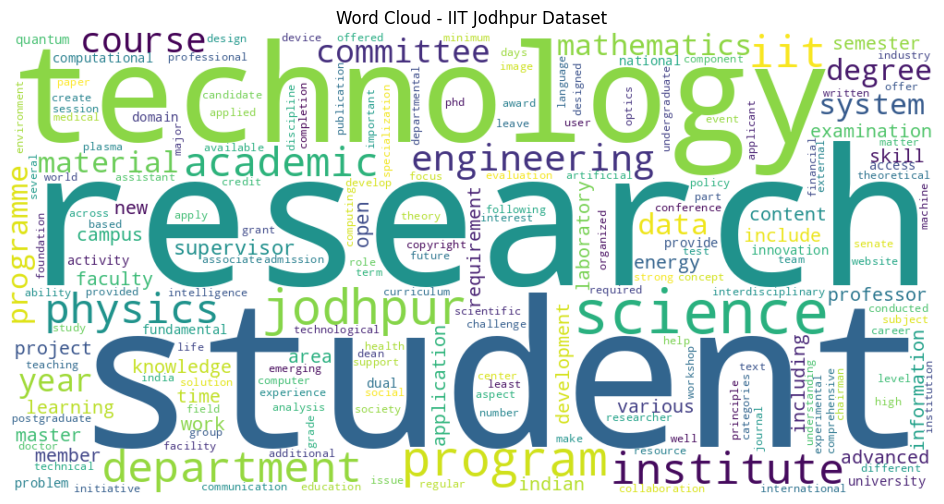

In [11]:
# Count word frequencies after removing stopwords
word_freq_nostop = Counter([word for sentence in processed_sentences_nostop for word in sentence])    # counting frequency of each word

# Top 20 frequent words (stopwords removed)
print("Top 20 Frequent Words (Stopwords Removed):")
for word, freq in word_freq_nostop.most_common(20):    # getting top 20 words
    print(word, ":", freq)    # printing word and its count

# Generate word cloud from stopword-free words
words_nostop = [word for sentence in processed_sentences_nostop for word in sentence]    # flattening words list

wordcloud_nostop = WordCloud(width=1000, height=500, background_color='white',collocations=False).generate(" ".join(words_nostop))    # creating word cloud

plt.figure(figsize=(12,6))    # setting figure size
plt.imshow(wordcloud_nostop, interpolation='bilinear')    # displaying word cloud
plt.axis('off')    # hiding axes
plt.title("Word Cloud - IIT Jodhpur Dataset")    # adding title
plt.show()    # showing plot

# Save word cloud for report
wordcloud_nostop.to_file("wordcloud_nostop.png")    # saving image file

model


In [12]:
import numpy as np    # importing numpy for numerical operations
import math    # importing math functions
import time    # importing time module
import random    # importing random module
import itertools    # importing itertools for combinations
from pathlib import Path    # importing Path for file handling

SEED = 2005    # setting seed value
random.seed(SEED)    # setting random seed
np.random.seed(SEED)    # setting numpy random seed

print('NumPy version:', np.__version__)    # printing numpy version
print('All imports OK — no ML libraries used for model training')    # confirmation message

NumPy version: 2.0.2
All imports OK — no ML libraries used for model training


In [13]:
# Use processed_sentences for Word2Vec (stopwords help in context)
# can also use processed_sentences_nostop if needed

TRAINING_SENTENCES = processed_sentences_nostop    # choosing sentences for training
MIN_COUNT = 2    # ignoring words with frequency < 2

# Count frequencies
all_words_flat = [w for sent in TRAINING_SENTENCES for w in sent]    # flattening all words
freq = Counter(all_words_flat)    # counting word frequency

# Build vocab
vocab_words = sorted([w for w, c in freq.items() if c >= MIN_COUNT])    # keeping words with min frequency
word2idx    = {w: i for i, w in enumerate(vocab_words)}    # mapping word to index
idx2word    = {i: w for w, i in word2idx.items()}    # mapping index to word
VOCAB_SIZE  = len(vocab_words)    # total vocab size

# Encode corpus as integer ids
token_ids = np.array(
    [word2idx[w] for sent in TRAINING_SENTENCES for w in sent if w in word2idx],    # converting words to ids
    dtype=np.int32
)

print(f'Vocabulary size (min_count={MIN_COUNT}) : {VOCAB_SIZE}')    # printing vocab size
print(f'Total training tokens                   : {len(token_ids)}')    # printing total tokens
print(f'Sample vocab words                      : {vocab_words[:15]}')    # printing sample words

Vocabulary size (min_count=2) : 2822
Total training tokens                   : 23776
Sample vocab words                      : ['aaai', 'abhirama', 'abilities', 'ability', 'able', 'absence', 'absolute', 'abstract', 'academia', 'academic', 'academics', 'academy', 'accelerated', 'accelerators', 'accenture']


In [14]:
# SIGMOID FUNCTION
def sigmoid(x):
    x = np.clip(x, -500, 500)    # limiting values to avoid overflow
    return 1.0 / (1.0 + np.exp(-x))    # applying sigmoid formula


# BINARY CROSS-ENTROPY LOSS
def bce_loss(p_hat, label):
    eps = 1e-10    # small value to avoid log(0)
    return -(label * math.log(p_hat + eps) + (1 - label) * math.log(1 - p_hat + eps))    # loss calculation


# NEGATIVE SAMPLER CLASS
class NegativeSampler:
    TABLE_SIZE = 1_000_000    # size of sampling table

    def __init__(self, token_ids, vocab_size):
        counts   = np.bincount(token_ids, minlength=vocab_size).astype(np.float64)    # count word frequency
        smoothed = counts ** 0.75    # smoothing distribution
        smoothed /= smoothed.sum()    # normalizing
        repeats  = np.round(smoothed * self.TABLE_SIZE).astype(np.int64)    # scaling counts
        self.table = np.repeat(np.arange(vocab_size, dtype=np.int32), repeats)    # creating sampling table
        np.random.shuffle(self.table)    # shuffle table
        self._ptr = 0    # pointer for sampling

    def sample(self, k, exclude=()):
        exclude = set(exclude)    # words to avoid
        samples = []
        while len(samples) < k:
            idx = int(self.table[self._ptr % len(self.table)])    # pick index
            self._ptr += 1
            if idx not in exclude:
                samples.append(idx)    # add valid sample
        return samples


# WEIGHT INITIALIZATION
def init_weights(vocab_size, embed_dim):
    W_in  = (np.random.rand(vocab_size, embed_dim) - 0.5) / embed_dim    # random small values
    W_out = np.zeros((vocab_size, embed_dim), dtype=np.float64)    # initialize with zeros
    return W_in, W_out


# LEARNING RATE DECAY
def linear_lr(initial_lr, min_lr, step, total_steps):
    progress = min(step / total_steps, 1.0)    # training progress
    return max(initial_lr * (1.0 - progress) + min_lr * progress, min_lr)    # updating learning rate


print('Core primitives ready: sigmoid, bce_loss, NegativeSampler, init_weights, linear_lr')    # confirmation

Core primitives ready: sigmoid, bce_loss, NegativeSampler, init_weights, linear_lr


In [19]:
def train_cbow(
    token_ids, vocab_size,
    embed_dim=100, window=5, n_neg=5,
    epochs=5, initial_lr=0.025, min_lr=0.0001,
):
    # CBOW Word2Vec training function

    W_in, W_out = init_weights(vocab_size, embed_dim)    # initialize weights
    sampler     = NegativeSampler(token_ids, vocab_size)    # create negative sampler
    N           = len(token_ids)    # total tokens
    total_steps = epochs * N    # total training steps
    loss_history = []    # store loss values

    for epoch in range(epochs):
        epoch_loss, epoch_pairs = 0.0, 0
        t0 = time.time()    # start time

        for pos in range(window, N - window):
            centre_idx   = int(token_ids[pos])    # center word index

            actual_win   = random.randint(1, window)    # dynamic window size

            ctx_ids = ([int(token_ids[i]) for i in range(pos - actual_win, pos)] +
                       [int(token_ids[i]) for i in range(pos + 1, pos + actual_win + 1)])    # context words

            if not ctx_ids:
                continue

            h = W_in[ctx_ids].mean(axis=0)    # average context embeddings

            pairs = [(centre_idx, 1)] + [
                (n, 0) for n in sampler.sample(n_neg, exclude=[centre_idx] + ctx_ids)
            ]    # positive + negative samples

            e = np.zeros(embed_dim)    # error vector

            for out_idx, label in pairs:
                score  = float(np.dot(h, W_out[out_idx]))    # dot product
                p_hat  = sigmoid(score)    # prediction
                epoch_loss += bce_loss(p_hat, label)    # loss update
                delta  = p_hat - label    # error

                step = epoch * N + pos
                lr   = linear_lr(initial_lr, min_lr, step, total_steps)    # learning rate

                W_out[out_idx] -= lr * delta * h    # update output weights
                e              += delta * W_out[out_idx]    # accumulate error
                epoch_pairs    += 1

            grad_in = e / len(ctx_ids)    # average gradient
            for c_idx in ctx_ids:
                W_in[c_idx] -= lr * grad_in    # update input weights

        avg = epoch_loss / max(epoch_pairs, 1)    # average loss
        loss_history.append(avg)
        print(f'  [CBOW] epoch {epoch+1}/{epochs}  loss={avg:.6f}  time={time.time()-t0:.1f}s')    # print progress

    return W_in, W_out, loss_history    # returning results


print('CBOW trainer defined')

CBOW trainer defined


In [20]:
def train_skipgram(
    token_ids, vocab_size,
    embed_dim=100, window=5, n_neg=5,
    epochs=5, initial_lr=0.025, min_lr=0.0001,
):
    # Skip-gram Word2Vec training function

    W_in, W_out = init_weights(vocab_size, embed_dim)    # initialize weights
    sampler     = NegativeSampler(token_ids, vocab_size)    # negative sampler
    N           = len(token_ids)    # total tokens
    total_steps = epochs * N    # total steps
    loss_history = []    # store loss

    for epoch in range(epochs):
        epoch_loss, epoch_pairs = 0.0, 0
        t0 = time.time()    # start time

        for pos in range(N):
            centre_idx = int(token_ids[pos])    # center word index
            actual_win = random.randint(1, window)    # dynamic window

            left  = max(0, pos - actual_win)
            right = min(N, pos + actual_win + 1)

            d_in = np.zeros(embed_dim)    # gradient accumulator

            for ctx_pos in range(left, right):
                if ctx_pos == pos:
                    continue
                ctx_idx = int(token_ids[ctx_pos])    # context word index

                pairs = [(ctx_idx, 1)] + [
                    (n, 0) for n in sampler.sample(n_neg, exclude=[centre_idx, ctx_idx])
                ]    # positive + negative samples

                for out_idx, label in pairs:
                    score  = float(np.dot(W_in[centre_idx], W_out[out_idx]))    # dot product
                    p_hat  = sigmoid(score)    # prediction
                    epoch_loss  += bce_loss(p_hat, label)    # loss update
                    epoch_pairs += 1
                    delta  = p_hat - label    # error

                    step = epoch * N + pos
                    lr   = linear_lr(initial_lr, min_lr, step, total_steps)    # learning rate

                    W_out[out_idx] -= lr * delta * W_in[centre_idx]    # update output weights
                    d_in           += delta * W_out[out_idx]    # accumulate gradient

            W_in[centre_idx] -= lr * d_in    # update center word embedding

        avg = epoch_loss / max(epoch_pairs, 1)    # average loss
        loss_history.append(avg)
        print(f'  [SG]   epoch {epoch+1}/{epochs}  loss={avg:.6f}  time={time.time()-t0:.1f}s')    # print progress

    return W_in, W_out, loss_history    # returning results


print('Skip-gram trainer defined')

Skip-gram trainer defined


In [21]:
# Hyperparameter grids
EMBED_DIMS  = [50, 100, 200]    # different embedding sizes
WINDOWS     = [3, 5, 7]    # different window sizes
NEG_SAMPLES = [5, 10, 15]    # number of negative samples
EPOCHS      = 5    # number of training epochs

all_results  = []    # store results of all runs
saved_models = {}    # store trained models

PROBE_WORDS = ['research', 'students', 'campus', 'technology', 'institute']    # test words

def vocab_coverage(words):
    return sum(1 for w in words if w in word2idx) / len(words)    # check how many words exist in vocab


def run_experiment(arch, embed_dim, window, n_neg):
    print(f'\n{"-"*55}')
    print(f'  {arch.upper()}  dim={embed_dim}  win={window}  neg={n_neg}')    # print config
    print(f'{"-"*55}')

    if arch == 'cbow':
        W_in, W_out, losses = train_cbow(
            token_ids, VOCAB_SIZE,
            embed_dim=embed_dim, window=window,
            n_neg=n_neg, epochs=EPOCHS,
        )    # run CBOW
    else:
        W_in, W_out, losses = train_skipgram(
            token_ids, VOCAB_SIZE,
            embed_dim=embed_dim, window=window,
            n_neg=n_neg, epochs=EPOCHS,
        )    # run Skip-gram

    cov = vocab_coverage(PROBE_WORDS)    # calculate coverage

    result = dict(
        arch=arch, embed_dim=embed_dim, window=window, n_neg=n_neg,
        vocab_size=VOCAB_SIZE, coverage=round(cov, 3),
        final_loss=round(losses[-1], 6), all_losses=losses,
    )    # store results

    all_results.append(result)    # add to results list
    saved_models[(arch, embed_dim, window, n_neg)] = W_in    # save model

    return result


print('Hyperparameter grid set up. Run the next two cells to train.')    # message

Hyperparameter grid set up. Run the next two cells to train.


In [22]:
# CBOW experiments (3 dims × 3 windows = 9 runs)
print('='*55)
print('CBOW EXPERIMENTS')
print('='*55)

cbow_runs = list(itertools.product(EMBED_DIMS, WINDOWS))    # all combinations of dim and window

for i, (dim, win) in enumerate(cbow_runs, 1):
    print(f'\n[{i}/{len(cbow_runs)}]', end='')    # show progress
    run_experiment('cbow', dim, win, n_neg=5)    # run CBOW experiment

print('\nAll CBOW experiments done')    # completion message

CBOW EXPERIMENTS

[1/9]
-------------------------------------------------------
  CBOW  dim=50  win=3  neg=5
-------------------------------------------------------
  [CBOW] epoch 1/5  loss=0.693145  time=3.4s
  [CBOW] epoch 2/5  loss=0.693129  time=3.5s
  [CBOW] epoch 3/5  loss=0.693062  time=4.6s
  [CBOW] epoch 4/5  loss=0.692893  time=3.6s
  [CBOW] epoch 5/5  loss=0.692710  time=3.8s

[2/9]
-------------------------------------------------------
  CBOW  dim=50  win=5  neg=5
-------------------------------------------------------
  [CBOW] epoch 1/5  loss=0.693146  time=4.8s
  [CBOW] epoch 2/5  loss=0.693136  time=3.6s
  [CBOW] epoch 3/5  loss=0.693097  time=3.8s
  [CBOW] epoch 4/5  loss=0.693001  time=4.8s
  [CBOW] epoch 5/5  loss=0.692892  time=3.6s

[3/9]
-------------------------------------------------------
  CBOW  dim=50  win=7  neg=5
-------------------------------------------------------
  [CBOW] epoch 1/5  loss=0.693146  time=3.7s
  [CBOW] epoch 2/5  loss=0.693139  time=4.6s

In [23]:
# Skip-gram experiments (3 dims × 3 windows × 3 neg_samples = 27 runs)
print('='*55)
print('SKIP-GRAM EXPERIMENTS')
print('='*55)

sg_runs = list(itertools.product(EMBED_DIMS, WINDOWS, NEG_SAMPLES))    # all combinations

for i, (dim, win, neg) in enumerate(sg_runs, 1):
    print(f'\n[{i}/{len(sg_runs)}]', end='')    # show progress
    run_experiment('skipgram', dim, win, neg)    # run Skip-gram experiment

print('\n All Skip-gram experiments done')    # completion message

SKIP-GRAM EXPERIMENTS

[1/27]
-------------------------------------------------------
  SKIPGRAM  dim=50  win=3  neg=5
-------------------------------------------------------
  [SG]   epoch 1/5  loss=0.688338  time=10.9s
  [SG]   epoch 2/5  loss=0.594614  time=10.8s
  [SG]   epoch 3/5  loss=0.506549  time=9.5s
  [SG]   epoch 4/5  loss=0.475893  time=10.6s
  [SG]   epoch 5/5  loss=0.467649  time=10.7s

[2/27]
-------------------------------------------------------
  SKIPGRAM  dim=50  win=3  neg=10
-------------------------------------------------------
  [SG]   epoch 1/5  loss=0.542129  time=18.9s
  [SG]   epoch 2/5  loss=0.327606  time=19.3s
  [SG]   epoch 3/5  loss=0.299250  time=18.6s
  [SG]   epoch 4/5  loss=0.294206  time=19.3s
  [SG]   epoch 5/5  loss=0.294782  time=18.2s

[3/27]
-------------------------------------------------------
  SKIPGRAM  dim=50  win=3  neg=15
-------------------------------------------------------
  [SG]   epoch 1/5  loss=0.419935  time=26.7s
  [SG]   epo

In [24]:
# Summary table
print(f"{'='*70}")
print(f"{'ARCH':<10} {'DIM':>5} {'WIN':>5} {'NEG':>5} {'VOCAB':>7} {'COVER':>7} {'FINAL LOSS':>12}")    # header
print(f"{'-'*70}")

for r in sorted(all_results, key=lambda x: (x['arch'], x['embed_dim'])):
    print(f"{r['arch']:<10} {r['embed_dim']:>5} {r['window']:>5} {r['n_neg']:>5} "
          f"{r['vocab_size']:>7} {r['coverage']:>7.3f} {r['final_loss']:>12.6f}")    # printing each result

print(f"{'='*70}")

# Select best model for each architecture
cbow_res = [r for r in all_results if r['arch'] == 'cbow']    # filter CBOW results
sg_res   = [r for r in all_results if r['arch'] == 'skipgram']    # filter Skip-gram results

best_cbow = min(cbow_res, key=lambda r: r['final_loss'])    # best CBOW (lowest loss)
best_sg   = min(sg_res,   key=lambda r: r['final_loss'])    # best Skip-gram

W_cbow = saved_models[('cbow', best_cbow['embed_dim'], best_cbow['window'], best_cbow['n_neg'])]    # get best CBOW model
W_sg   = saved_models[('skipgram', best_sg['embed_dim'], best_sg['window'], best_sg['n_neg'])]    # get best SG model

print(f"\nBest CBOW      : dim={best_cbow['embed_dim']}  win={best_cbow['window']}  loss={best_cbow['final_loss']:.6f}")    # print best CBOW
print(f"Best Skip-gram : dim={best_sg['embed_dim']}  win={best_sg['window']}  neg={best_sg['n_neg']}  loss={best_sg['final_loss']:.6f}")    # print best SG

ARCH         DIM   WIN   NEG   VOCAB   COVER   FINAL LOSS
----------------------------------------------------------------------
cbow          50     3     5    2822   0.800     0.692710
cbow          50     5     5    2822   0.800     0.692892
cbow          50     7     5    2822   0.800     0.692939
cbow         100     3     5    2822   0.800     0.693024
cbow         100     5     5    2822   0.800     0.693022
cbow         100     7     5    2822   0.800     0.693021
cbow         200     3     5    2822   0.800     0.693062
cbow         200     5     5    2822   0.800     0.693072
cbow         200     7     5    2822   0.800     0.693079
skipgram      50     3     5    2822   0.800     0.467649
skipgram      50     3    10    2822   0.800     0.294782
skipgram      50     3    15    2822   0.800     0.224166
skipgram      50     5     5    2822   0.800     0.433586
skipgram      50     5    10    2822   0.800     0.287208
skipgram      50     5    15    2822   0.800     0.220324
s

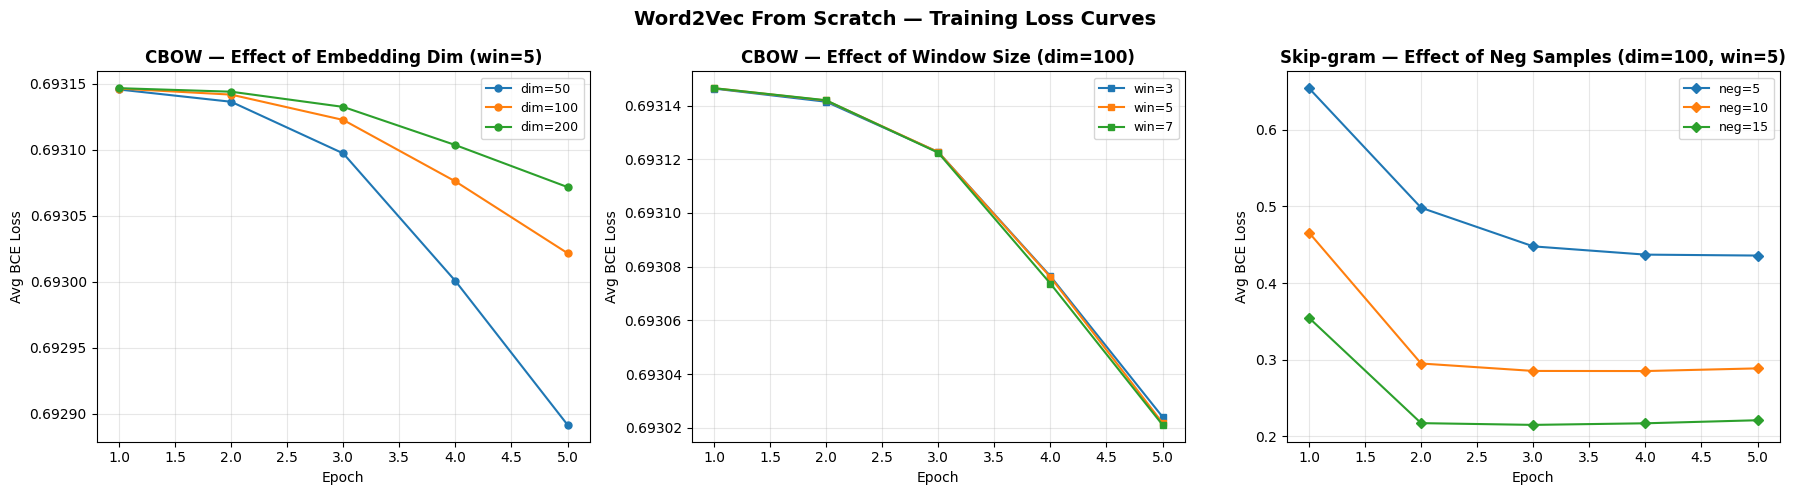

✅ Saved → training_loss_curves.png


In [25]:
# Loss curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))    # create 3 plots

# Plot 1: CBOW — effect of embedding dim
ax = axes[0]
for r in [r for r in cbow_res if r['window'] == 5]:
    ax.plot(range(1, len(r['all_losses'])+1), r['all_losses'],
            marker='o', markersize=5, label=f"dim={r['embed_dim']}")    # plot loss vs epochs

ax.set_title('CBOW — Effect of Embedding Dim (win=5)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Avg BCE Loss')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Plot 2: CBOW — effect of window size
ax = axes[1]
for r in [r for r in cbow_res if r['embed_dim'] == 100]:
    ax.plot(range(1, len(r['all_losses'])+1), r['all_losses'],
            marker='s', markersize=5, label=f"win={r['window']}")    # plot for different windows

ax.set_title('CBOW — Effect of Window Size (dim=100)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Avg BCE Loss')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Plot 3: Skip-gram — effect of negative samples
ax = axes[2]
for r in [r for r in sg_res if r['embed_dim'] == 100 and r['window'] == 5]:
    ax.plot(range(1, len(r['all_losses'])+1), r['all_losses'],
            marker='D', markersize=5, label=f"neg={r['n_neg']}")    # plot for different negative samples

ax.set_title('Skip-gram — Effect of Neg Samples (dim=100, win=5)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Avg BCE Loss')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Word2Vec From Scratch — Training Loss Curves', fontsize=14, fontweight='bold')    # main title
plt.tight_layout()

plt.savefig('training_loss_curves.png', dpi=150, bbox_inches='tight')    # save figure
plt.show()    # display plots

print('✅ Saved → training_loss_curves.png')    # confirmation

---
## Task 3 — Semantic Analysis
All evaluation built from scratch using cosine similarity.
- **3A:** Top-5 nearest neighbours for 5 query words
- **3B:** Analogy experiments using 3CosAdd vector arithmetic
- **3C:** CBOW vs Skip-gram comparison + cosine similarity heatmap

In [26]:
# COSINE SIMILARITY
def cosine_similarity(a, b):
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-10    # compute denominator
    return float(np.dot(a, b) / denom)    # similarity formula


# NEAREST NEIGHBOURS
def nearest_neighbours(word, W, topn=5):
    if word not in word2idx:
        return None    # check if word exists

    qvec  = W[word2idx[word]]    # get word vector
    norms = np.linalg.norm(W, axis=1) + 1e-10    # norms of all vectors
    sims  = (W @ qvec) / (norms * (np.linalg.norm(qvec) + 1e-10))    # cosine similarity

    sims[word2idx[word]] = -999.0    # remove self

    top_idx = np.argsort(sims)[::-1][:topn]    # top similar words
    return [(idx2word[i], round(float(sims[i]), 4)) for i in top_idx]    # return results


# ANALOGY FUNCTION
def analogy(a, b, c, W, topn=5):
    for w in [a, b, c]:
        if w not in word2idx:
            return None, f"'{w}' not in vocabulary"    # check words exist

    query = W[word2idx[b]] - W[word2idx[a]] + W[word2idx[c]]    # vector operation

    norms = np.linalg.norm(W, axis=1) + 1e-10
    sims  = (W @ query) / (norms * (np.linalg.norm(query) + 1e-10))    # similarity

    for w in [a, b, c]:
        sims[word2idx[w]] = -999.0    # exclude input words

    top_idx = np.argsort(sims)[::-1][:topn]    # get top results
    results = [(idx2word[i], round(float(sims[i]), 4)) for i in top_idx]

    return results[0][0], results    # best match + list


print('Evaluation utilities defined: cosine_similarity, nearest_neighbours, analogy')

Evaluation utilities defined: cosine_similarity, nearest_neighbours, analogy


In [29]:
# Query words
QUERY_WORDS = ['research', 'student', 'campus', 'phd', 'exam']    # words to test

print('='*60)
print('TOP-5 NEAREST NEIGHBOURS')
print('='*60)

for arch_label, W in [('CBOW (best)', W_cbow), ('Skip-gram (best)', W_sg)]:
    print(f'\n── {arch_label} ──────────────────────────────')    # model name

    for word in QUERY_WORDS:
        nbrs = nearest_neighbours(word, W, topn=5)    # get neighbours
        print(f'\n  Query: "{word}"')

        if nbrs:
            for rank, (w, sim) in enumerate(nbrs, 1):
                bar = '█' * int(abs(sim) * 20)    # simple bar visualization
                print(f'    {rank}. {w:<22s}  cos={sim:+.4f}  {bar}')    # print result
        else:
            print('    (word not in vocabulary)')    # if word not found

TOP-5 NEAREST NEIGHBOURS

── CBOW (best) ──────────────────────────────

  Query: "research"
    1. student                 cos=+0.9741  ███████████████████
    2. academic                cos=+0.9456  ██████████████████
    3. department              cos=+0.9401  ██████████████████
    4. program                 cos=+0.9361  ██████████████████
    5. institute               cos=+0.9326  ██████████████████

  Query: "student"
    1. research                cos=+0.9741  ███████████████████
    2. program                 cos=+0.9659  ███████████████████
    3. department              cos=+0.9532  ███████████████████
    4. academic                cos=+0.9518  ███████████████████
    5. course                  cos=+0.9514  ███████████████████

  Query: "campus"
    1. program                 cos=+0.8654  █████████████████
    2. student                 cos=+0.8628  █████████████████
    3. technology              cos=+0.8421  ████████████████
    4. academic                cos=+0.8408  ███

In [55]:
# Analogy experiments
ANALOGY_EXPERIMENTS = [
    ('teaching : scholarship :: research : ?',    'teaching',    'scholarship', 'research'),
    ('student : hostel :: faculty : ?',           'student',    'hostel',      'faculty'),
    ('campus : permanent :: institute : ?',       'campus',      'permanent',   'institute'),
    ('technology : education :: research : ?',    'technology',  'education',   'research'),
    ('sports : facility :: academic : ?',         'sports',      'facility',    'academic'),
    ('jodhpur : campus :: india : ?',             'jodhpur',     'campus',      'india'),
     ('course : syllabus :: research : ?',      'course',       'syllabus',    'research'),
]    # analogy test cases

print('='*60)
print('ANALOGY EXPERIMENTS  (A : B :: C : ?)')
print('Method: vec(B) - vec(A) + vec(C) → nearest word')
print('='*60)

for arch_label, W in [('CBOW', W_cbow), ('Skip-gram', W_sg)]:
    print(f'\n── {arch_label} ──────────────────────────────')    # model name

    for desc, a, b, c in ANALOGY_EXPERIMENTS:
        result, top5 = analogy(a, b, c, W, topn=5)    # solve analogy
        print(f'\n  {desc}')

        if isinstance(top5, str):
            print(f'    [SKIP] {top5}')    # if word missing
        else:
            print(f'    Predicted : {result}')    # best result
            print(f'    Top-5     : {[w for w, _ in top5]}')    # top 5 words

ANALOGY EXPERIMENTS  (A : B :: C : ?)
Method: vec(B) - vec(A) + vec(C) → nearest word

── CBOW ──────────────────────────────

  teaching : scholarship :: research : ?
    Predicted : student
    Top-5     : ['student', 'academic', 'department', 'physics', 'program']

  student : hostel :: faculty : ?
    Predicted : squid
    Top-5     : ['squid', 'proportional', 'random', 'healthy', 'spread']

  campus : permanent :: institute : ?
    Predicted : research
    Top-5     : ['research', 'technology', 'department', 'student', 'course']

  technology : education :: research : ?
    Predicted : student
    Top-5     : ['student', 'academic', 'committee', 'physics', 'course']

  sports : facility :: academic : ?
    Predicted : student
    Top-5     : ['student', 'research', 'program', 'institute', 'department']

  jodhpur : campus :: india : ?
    Predicted : absolute
    Top-5     : ['absolute', 'still', 'creator', 'commons', 'avoided']

  course : syllabus :: research : ?
    Predicted :

In [ ]:
# ── Side-by-side neighbour comparison ────────────────────────────────────
print(f"\n{'='*72}")
print('ARCHITECTURE COMPARISON: CBOW  vs  SKIP-GRAM')
print(f"{'='*72}")
print(f"  {'WORD':<18} {'CBOW top-5':<36} {'SKIPGRAM top-5'}")
print(f"  {'-'*18} {'-'*36} {'-'*36}")
for word in QUERY_WORDS:
    c_nb = nearest_neighbours(word, W_cbow, topn=5) or []
    s_nb = nearest_neighbours(word, W_sg,   topn=5) or []
    c_str = ', '.join([w for w, _ in c_nb]) if c_nb else 'N/A'
    s_str = ', '.join([w for w, _ in s_nb]) if s_nb else 'N/A'
    print(f'  {word:<18} {c_str[:35]:<36} {s_str[:35]}')



ARCHITECTURE COMPARISON: CBOW  vs  SKIP-GRAM
  WORD               CBOW top-5                           SKIPGRAM top-5
  ------------------ ------------------------------------ ------------------------------------
  research           student, academic, department, prog  interdisciplinary, departmental, te
  student            research, program, department, acad  register, regular, full, campus, le
  campus             program, student, technology, acade  community, register, leave, life, e
  technology         department, institute, program, stu  indian, emerging, education, comput
  institute          technology, research, student, depa  indian, currently, organized, follo


---
## Task 4 — Visualisation: PCA & t-SNE
Both dimensionality reduction methods implemented **from scratch** using NumPy only.
- **PCA** — via manual SVD (`np.linalg.svd`)
- **t-SNE** — full implementation: binary search for σᵢ, symmetrised P, Student-t Q, KL gradient, momentum SGD

In [43]:
# ─────────────────────────────────────────────────────────────────────────
# PCA FROM SCRATCH — via SVD
# Steps:
#   1. Centre the data (subtract column means)
#   2. SVD:  X = U Σ Vᵀ
#   3. Project onto first 2 right-singular vectors
# ─────────────────────────────────────────────────────────────────────────
def pca_2d(W):
    X = W - W.mean(axis=0)                          # centre
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    coords    = X @ Vt[:2].T                         # project onto top-2 PCs
    var_ratio = (s[:2]**2) / (s**2).sum()
    return coords, var_ratio


# ─────────────────────────────────────────────────────────────────────────
# t-SNE FROM SCRATCH
# Full implementation of van der Maaten & Hinton (2008)
# ─────────────────────────────────────────────────────────────────────────
def tsne_2d(W, perplexity=20, n_iter=500, lr=150.0, seed=42):
    np.random.seed(seed)
    n = W.shape[0]
    perplexity = min(perplexity, max(5, (n - 1) // 3))

    # Step 1: pairwise squared distances in high-D
    sum_sq = np.sum(W ** 2, axis=1)
    D2     = np.maximum(sum_sq[:, None] + sum_sq[None, :] - 2 * W @ W.T, 0.0)
    np.fill_diagonal(D2, 0.0)

    # Step 2: conditional probabilities via binary search for σᵢ
    target_H = math.log(perplexity)
    P_cond   = np.zeros((n, n))
    for i in range(n):
        lo, hi, beta = 1e-20, 1e10, 1.0
        for _ in range(50):
            exp_D = np.exp(-beta * D2[i]); exp_D[i] = 0.0
            denom = exp_D.sum() + 1e-10
            p     = exp_D / denom
            nz    = p > 1e-10
            H     = -np.sum(p[nz] * np.log(p[nz]))
            if abs(H - target_H) < 1e-5: break
            if H < target_H: hi = beta; beta = (lo + hi) / 2.0
            else:             lo = beta; beta = (lo + hi) / 2.0
        P_cond[i] = p

    # Step 3: symmetrise + early exaggeration
    P  = np.maximum((P_cond + P_cond.T) / (2.0 * n), 1e-12)
    P *= 4.0

    # Step 4: initialise low-D embedding
    Y     = np.random.randn(n, 2) * 1e-4
    Y_old = Y.copy()
    gains = np.ones_like(Y)
    mom   = 0.5

    for t in range(n_iter):
        diff = Y[:, None, :] - Y[None, :, :]        # (n, n, 2)
        d2   = (diff ** 2).sum(axis=2)               # (n, n)
        num  = 1.0 / (1.0 + d2)
        np.fill_diagonal(num, 0.0)
        Q    = np.maximum(num / (num.sum() + 1e-10), 1e-12)
        grad = 4.0 * ((P - Q)[:, :, None] * diff * num[:, :, None]).sum(axis=1)
        same_sign = (np.sign(grad) == np.sign(Y - Y_old))
        gains     = np.where(same_sign, gains * 0.8, gains + 0.2).clip(min=0.01)
        Y_new     = Y - lr * gains * grad + mom * (Y - Y_old)
        Y_old, Y  = Y.copy(), Y_new
        Y        -= Y.mean(axis=0)
        if t == 100: P /= 4.0; mom = 0.8

    return Y


print('PCA (manual SVD) and t-SNE (from scratch) defined')


PCA (manual SVD) and t-SNE (from scratch) defined


In [48]:
from matplotlib.lines import Line2D

# ── Semantic clusters — words from YOUR IIT Jodhpur corpus ────────────────
CLUSTERS = {
    'Academic':       {'words': ['research', 'scholarship', 'teaching', 'learning',
                                  'academic', 'education', 'technology', 'science'],
                       'color': '#E8593C', 'marker': 'o'},
    'Student Life':   {'words': ['students', 'hostel', 'sports', 'facilities',
                                  'development', 'programs', 'activities'],
                       'color': '#1D9E75', 'marker': 's'},
    'Infrastructure': {'words': ['campus', 'permanent', 'residential', 'sprawling',
                                  'building', 'rooms', 'floor', 'acres'],
                       'color': '#378ADD', 'marker': '^'},
    'Governance':     {'words': ['institute', 'committed', 'india', 'government',
                                  'ministry', 'established', 'national'],
                       'color': '#7F77DD', 'marker': 'D'},
    'Services':       {'words': ['faculty', 'staff', 'medical', 'transport',
                                  'provided', 'available', 'services'],
                       'color': '#BA7517', 'marker': 'P'},
}

def collect_vecs(W):
    words, vecs, labels, colors, markers = [], [], [], [], []
    for cname, ci in CLUSTERS.items():
        for w in ci['words']:
            if w in word2idx:
                words.append(w); vecs.append(W[word2idx[w]])
                labels.append(cname); colors.append(ci['color']); markers.append(ci['marker'])
    return words, np.array(vecs, dtype=np.float64), labels, colors, markers

def make_legend():
    return [Line2D([0],[0], marker=ci['marker'], color='w',
                   markerfacecolor=ci['color'], markersize=9, label=cn)
            for cn, ci in CLUSTERS.items()]

cbow_w, cbow_v, cbow_lbl, cbow_col, cbow_mk = collect_vecs(W_cbow)
sg_w,   sg_v,   sg_lbl,   sg_col,   sg_mk   = collect_vecs(W_sg)
print(f'Cluster words found — CBOW: {len(cbow_w)}  |  Skip-gram: {len(sg_w)}')


Cluster words found — CBOW: 32  |  Skip-gram: 32


In [46]:


print('Running t-SNE from scratch (may take 2–5 min)...')
cbow_tsne = tsne_2d(cbow_v, perplexity=15, n_iter=500)
sg_tsne   = tsne_2d(sg_v,   perplexity=15, n_iter=500)
print('t-SNE done.')


Running t-SNE from scratch (may take 2–5 min)...
t-SNE done.


In [51]:
def scatter(ax, coords, words, colors, markers, title, xlabel, ylabel):
    ax.set_facecolor('#FAFAF8')
    for i, (w, c, m) in enumerate(zip(words, colors, markers)):
        ax.scatter(coords[i,0], coords[i,1], c=c, marker=m,
                   s=100, alpha=0.85, edgecolors='white', linewidths=0.7, zorder=3)
        ax.annotate(w, (coords[i,0], coords[i,1]), fontsize=8, alpha=0.9,
                    xytext=(4,4), textcoords='offset points')
    ax.set_title(title, fontweight='bold', fontsize=11, pad=10)
    ax.set_xlabel(xlabel, fontsize=9); ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.spines[['top','right']].set_visible(False)



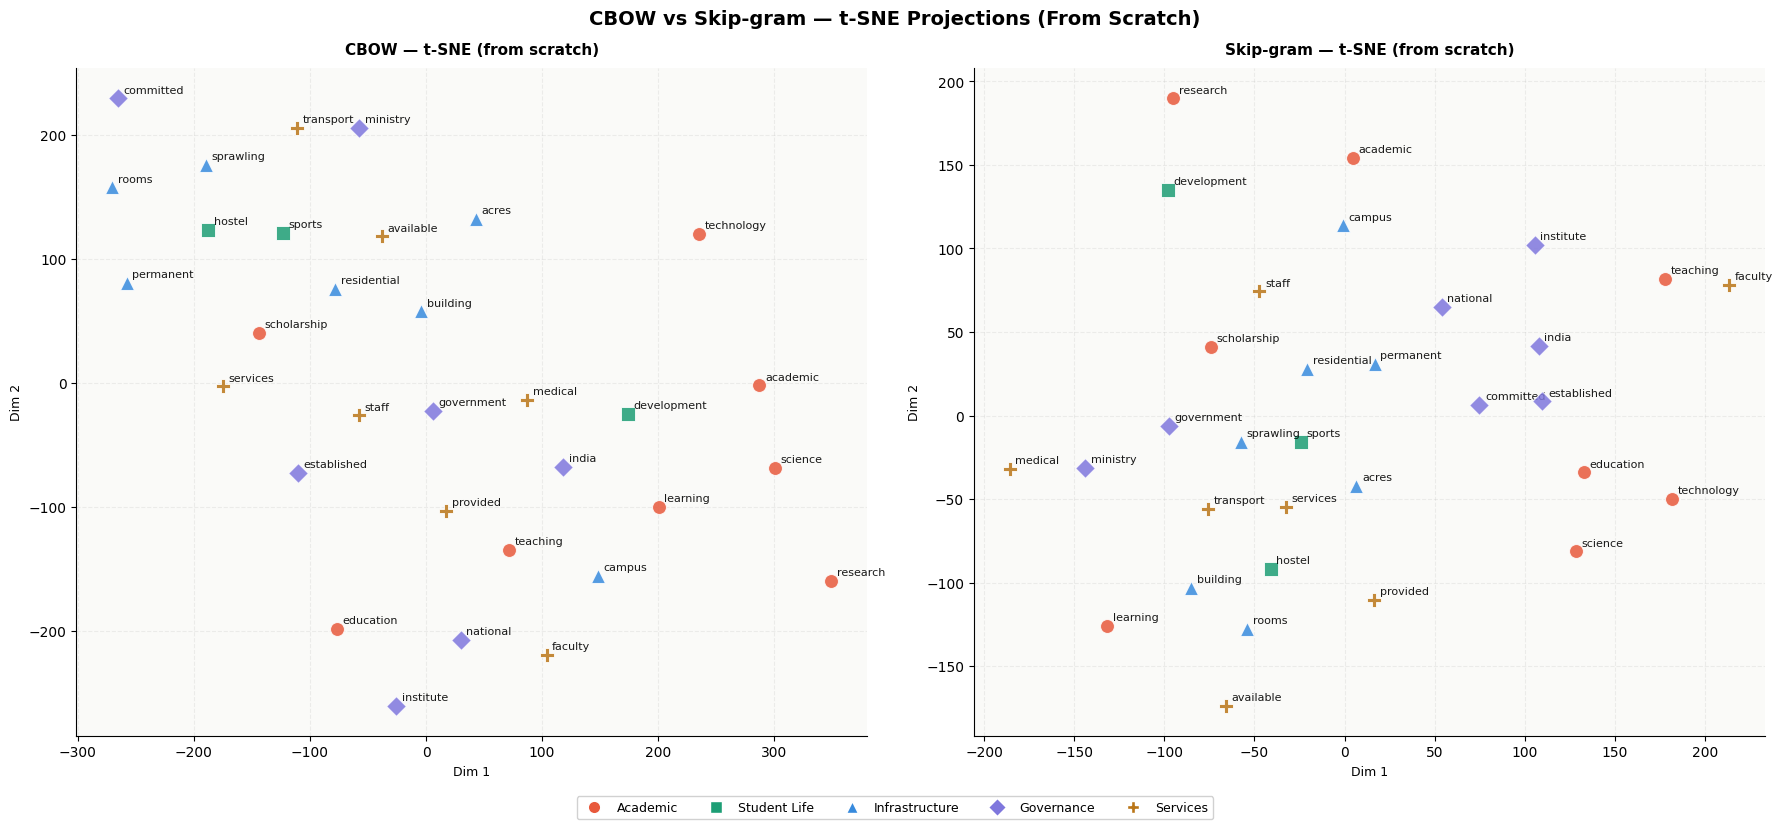

✅ Saved → tsne_comparison.png


In [52]:
# ── t-SNE: CBOW vs Skip-gram side by side ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
scatter(axes[0], cbow_tsne, cbow_w, cbow_col, cbow_mk,
        'CBOW — t-SNE (from scratch)', 'Dim 1', 'Dim 2')
scatter(axes[1], sg_tsne, sg_w, sg_col, sg_mk,
        'Skip-gram — t-SNE (from scratch)', 'Dim 1', 'Dim 2')
fig.legend(handles=make_legend(), loc='lower center', ncol=5,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))
plt.suptitle('CBOW vs Skip-gram — t-SNE Projections (From Scratch)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → tsne_comparison.png')


In [53]:
# ── Silhouette score from scratch ─────────────────────────────────────────
# Measures cluster separation: higher is better
def silhouette_scratch(coords, labels):
    unique_labels = list(set(labels))
    if len(unique_labels) < 2:
        return None
    label_arr = np.array(labels)
    n         = len(coords)
    scores    = []
    for i in range(n):
        same  = coords[label_arr == label_arr[i]]
        # a(i) = mean distance to same-cluster points
        a = np.mean(np.linalg.norm(same - coords[i], axis=1)) if len(same) > 1 else 0.0
        # b(i) = min mean distance to any other cluster
        b_vals = []
        for lbl in unique_labels:
            if lbl == label_arr[i]: continue
            other = coords[label_arr == lbl]
            if len(other) > 0:
                b_vals.append(np.mean(np.linalg.norm(other - coords[i], axis=1)))
        b = min(b_vals) if b_vals else 0.0
        scores.append((b - a) / max(a, b) if max(a, b) > 0 else 0.0)
    return round(float(np.mean(scores)), 4)

print('='*55)
print('CLUSTER SEPARATION — Silhouette Score (higher = better)')
print('='*55)
for arch, pca_c, tsne_c, lbs in [
    ('CBOW',      cbow_pca, cbow_tsne, cbow_lbl),
    ('Skip-gram', sg_pca,   sg_tsne,   sg_lbl),
]:
    ps = silhouette_scratch(pca_c,  lbs)
    ts = silhouette_scratch(tsne_c, lbs)
    print(f'  {arch:<12}  PCA silhouette = {ps}   t-SNE silhouette = {ts}')


CLUSTER SEPARATION — Silhouette Score (higher = better)
  CBOW          PCA silhouette = -0.1148   t-SNE silhouette = 0.0076
  Skip-gram     PCA silhouette = 0.0132   t-SNE silhouette = -0.0189


In [ ]:
!pip install beautifulsoup4

import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin, urlparse
import time

# Starting URL
start_url = "https://www.iitj.ac.in/"  # change this

visited = set()
to_visit = [start_url]
corpus = []

MAX_PAGES = 20

def is_valid(url, base_domain):
    parsed = urlparse(url)
    return parsed.netloc == base_domain or parsed.netloc == ""

base_domain = urlparse(start_url).netloc

while to_visit and len(visited) < MAX_PAGES:
    url = to_visit.pop(0)

    if url in visited:
        continue

    try:
        print(f"Scraping: {url}")
        response = requests.get(url, timeout=5)

        if response.status_code != 200:
            continue

        soup = BeautifulSoup(response.text, "html.parser")

        # Extract text
        paragraphs = soup.find_all("p")
        for para in paragraphs:
            text = para.get_text(strip=True)
            if text:
                corpus.append(text)

        visited.add(url)

        # Find new links
        for link in soup.find_all("a", href=True):
            new_url = urljoin(url, link['href'])

            # Stay within same domain
            if is_valid(new_url, base_domain) and new_url not in visited:
                to_visit.append(new_url)

        time.sleep(1)  # be polite

    except Exception as e:
        print(f"Error: {e}")

# Save corpus
with open("corpus.txt", "w", encoding="utf-8") as f:
    for line in corpus:
        f.write(line + "\n")

print(f"\nDone! Scraped {len(visited)} pages.")

  saved: cbow_model.pkl
  saved: skipgram_model.pkl
  added: clean_corpus.txt
  added: clean_corpus_sentences_nostop.txt
  added: wordcloud_nostop.png
  added: training_loss_curves.png
  skipped (not found): heatmaps.png
  added: pca_comparison.png
  added: tsne_comparison.png
  added: cbow_model.pkl
  added: skipgram_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download started


In [36]:
# Choose a word from the vocabulary (e.g., 'research')
chosen_word = 'research'

# Check if the word exists in the vocabulary
if chosen_word in word2idx:
    # Get the index of the chosen word
    word_index = word2idx[chosen_word]

    # Retrieve the embedding vector from the best Skip-gram model (W_sg)
    # The best Skip-gram model has an embedding dimension of 50 as seen in `best_sg`
    embedding_vector = W_sg[word_index]

    # Format the vector as a comma-separated string with 4 decimal places
    formatted_vector = ', '.join([f'{x:.4f}' for x in embedding_vector])

    # Print the word and its embedding vector
    print(f"{chosen_word} :{ {formatted_vector} }")
else:
    print(f"The word '{chosen_word}' is not in the vocabulary.")

research :{'-0.8360, -0.8675, -0.5935, 0.5247, 0.0577, 1.1231, -0.0058, -0.1425, -0.1199, 0.9258, -0.9535, 0.1776, -0.5772, -0.9426, -0.1479, 0.0503, -0.1663, 0.3606, -0.6884, -0.1221, -0.8157, 0.1117, 0.1343, 1.7550, 1.8916, 0.9212, 0.1378, 1.6171, 0.5652, 1.4214, -0.1906, 1.3027, 0.4065, -0.4974, -0.2272, 0.6289, 0.6715, -0.4871, -0.6100, -0.4700, -1.2636, -1.3333, -1.4374, -0.0727, -1.1393, 0.9434, -0.4639, -0.6734, 0.5235, 0.6542'}
